# 🔄 NeuralVision Pipeline — Retrain Notebook

This notebook **retrains** an existing DenseNet model using a combination of:
- **Old data** (already in Google Drive)
- **New data** (uploaded via the app → saved to Drive)

**Steps:**
1. Mount Google Drive
2. Load existing model from Drive as pretrained weights
3. Merge old + new data
4. Preprocess & augment
5. Retrain (fine-tune top-30 layers)
6. Evaluate & compare against previous model
7. Save best model back to Drive

> ⚡ Ensure **Runtime → Change runtime type → GPU (T4)** is selected.

## Import Packages

In [43]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from google.colab import drive
import shutil
import re
import zipfile

# sklearn imports
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

# tensorflow imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

from tensorflow.keras.applications import densenet

## Load From google drive

In [23]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import os

BASE_PATH = '/content/drive/MyDrive/ml_pipeline project/'

OLD_DATA = os.path.join(BASE_PATH, 'old_data')
NEW_DATA = os.path.join(BASE_PATH, 'data/newdata_20260402_030846.zip')
# /content/drive/MyDrive/ml_pipeline project/data/newdata_20260402_030846.zip
MODELS_PATH = os.path.join(BASE_PATH, 'models')

COMBINED_DATA = '/content/combined_data'
model_local = '/content/models'

os.makedirs(COMBINED_DATA, exist_ok=True)

## Combine datasets

In [6]:
import zipfile

unzip_folder = '/content/unzipped_new_data'

os.makedirs(unzip_folder, exist_ok=True)

with zipfile.ZipFile(NEW_DATA, 'r') as zip_ref:
    zip_ref.extractall(unzip_folder)

In [7]:
import shutil

macosx_folder = os.path.join(unzip_folder, '__MACOSX')
if os.path.exists(macosx_folder):
    shutil.rmtree(macosx_folder)

In [8]:
new_data_path = '/content/unzipped_new_data/future_data'

In [9]:
import os
import shutil

def copy_data(src, dst, valid_extensions=('.jpg', '.jpeg', '.png')):
    """
    Recursively copy image files from src to dst.
    - Ignores hidden files/folders like .DS_Store and __MACOSX
    - Handles nested folders
    """
    for class_name in os.listdir(src):
        # Skip hidden/system files
        if class_name.startswith('.') or class_name == '__MACOSX':
            continue

        class_src = os.path.join(src, class_name)
        class_dst = os.path.join(dst, class_name)
        os.makedirs(class_dst, exist_ok=True)

        # Walk through class_src recursively
        for root, dirs, files in os.walk(class_src):
            for f in files:
                if f.lower().endswith(valid_extensions):
                    shutil.copy(os.path.join(root, f), class_dst)
                else:
                    print(f"Skipping non-image file: {os.path.join(root, f)}")

In [10]:
copy_data(OLD_DATA, COMBINED_DATA)
copy_data(new_data_path, COMBINED_DATA)

print("✅ Data combined successfully")

Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (83).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (77).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (34).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (39).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (48).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (5).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (13).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (12).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipeline project/old_data/Brain Tumor/Cancer (46).tif
Skipping non-image file: /content/drive/MyDrive/ml_pipel

## Define generators for train and test

In [30]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=densenet.preprocess_input,
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    COMBINED_DATA,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    COMBINED_DATA,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

print(train_generator.class_indices)

Found 3612 images belonging to 2 classes.
Found 902 images belonging to 2 classes.
{'Brain Tumor': 0, 'Healthy': 1}


## Get Latest Model

In [31]:
def get_latest_model(models_path):
    model_files = [f for f in os.listdir(models_path) if f.endswith('.keras')]

    versions = []
    for f in model_files:
        match = re.search(r'v(\d+)', f)
        if match:
            versions.append((int(match.group(1)), f))

    latest_model = sorted(versions, reverse=True)[0][1]
    return latest_model

latest_model_name = get_latest_model(MODELS_PATH)
latest_model_path = os.path.join(MODELS_PATH, latest_model_name)

print("Loading:", latest_model_name)

Loading: model_v1.keras


In [32]:
model = load_model(latest_model_path)

## Retrain Model

In [33]:
# Freeze most layers (fine-tuning)
for layer in model.layers[:-5]:
    layer.trainable = False

# Always recompile after changing trainable layers
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Base layers frozen, model recompiled")

✅ Base layers frozen, model recompiled


In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_path = os.path.join(model_local, 'temp_best_model.keras')

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [35]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[checkpoint]
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.8216 - loss: 0.4408
Epoch 1: val_loss improved from None to 0.36539, saving model to /content/models/temp_best_model.keras

Epoch 1: finished saving model to /content/models/temp_best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 116s 817ms/step - accuracy: 0.8355 - loss: 0.3897 - val_accuracy: 0.8503 - val_loss: 0.3654
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8610 - loss: 0.3229
Epoch 2: val_loss improved from 0.36539 to 0.34282, saving model to /content/models/temp_best_model.keras

Epoch 2: finished saving model to /content/models/temp_best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 60s 532ms/step - accuracy: 0.8558 - loss: 0.3417 - val_accuracy: 0.8625 - val_loss: 0.3428
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.8562 - loss: 0.3384
Epoch 3: val_loss improved from 0.34282 to 0.30931, saving model to /content/models/temp_best_model.keras

Epoch 3: finished saving model to /c

## Load the Best Model Before Saving Version

In [36]:
model = load_model(checkpoint_path)
print("✅ Loaded best model from checkpoint")

✅ Loaded best model from checkpoint


##Save as vN+1 (Final Step)

In [39]:
def get_next_version(models_path):
    model_files = [f for f in os.listdir(models_path) if f.endswith('.keras')]

    versions = []
    for f in model_files:
        match = re.search(r'v(\d+)', f)
        if match:
            versions.append(int(match.group(1)))

    next_version = max(versions) + 1
    return next_version


In [40]:
next_version = get_next_version(MODELS_PATH)
new_model_name = f'densenet_v{next_version}.keras'

save_path = os.path.join(MODELS_PATH, new_model_name)

model.save(save_path)

print("✅ Saved new model as:", new_model_name)

✅ Saved new model as: densenet_v2.keras


## Check performance

In [41]:
# -----------------------------
# Helper Function 1: Compute Metrics
# -----------------------------
def compute_metrics(model, generator):
    """
    Compute accuracy, precision, recall, f1-score for a model on a generator.

    Args:
        model : Trained Keras model
        generator : Keras ImageDataGenerator (test/validation set)

    Returns:
        metrics_dict : dictionary with 'accuracy', 'precision', 'recall', 'f1_score'
        y_true, y_pred : arrays for further use (e.g., confusion matrix)
    """
    generator.reset()  # ensure generator starts from beginning
    y_pred_prob = model.predict(generator, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = generator.classes

    metrics_dict = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred)
    }
    return metrics_dict, y_true, y_pred


# -----------------------------
# Helper Function 2: Confusion Matrix
# -----------------------------
def plot_confusion_matrix(y_true, y_pred, class_names=['Normal','Tumor'], figsize=(6,6), cmap='Blues'):
    """
    Plot a confusion matrix using seaborn heatmap.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()



# -----------------------------
# Helper Function 3: Training History Plot
# -----------------------------
def plot_training_history(history, model_name='Model'):
    """
    Plot training and validation accuracy & loss curves.
    """
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Validation')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

{'accuracy': 0.47339246119733924, 'precision': 0.4292682926829268, 'recall': 0.42206235011990406, 'f1_score': 0.42563482466747277}


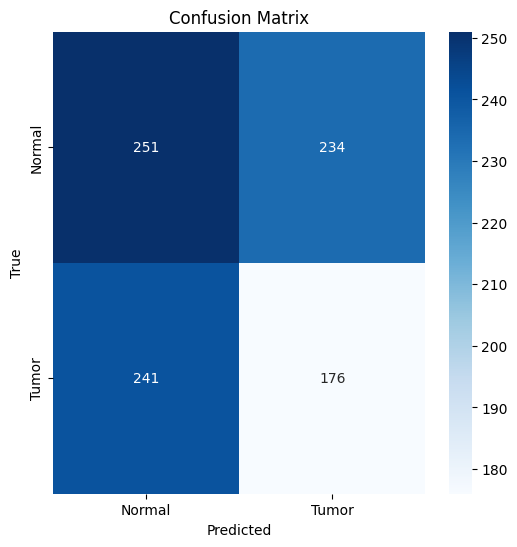

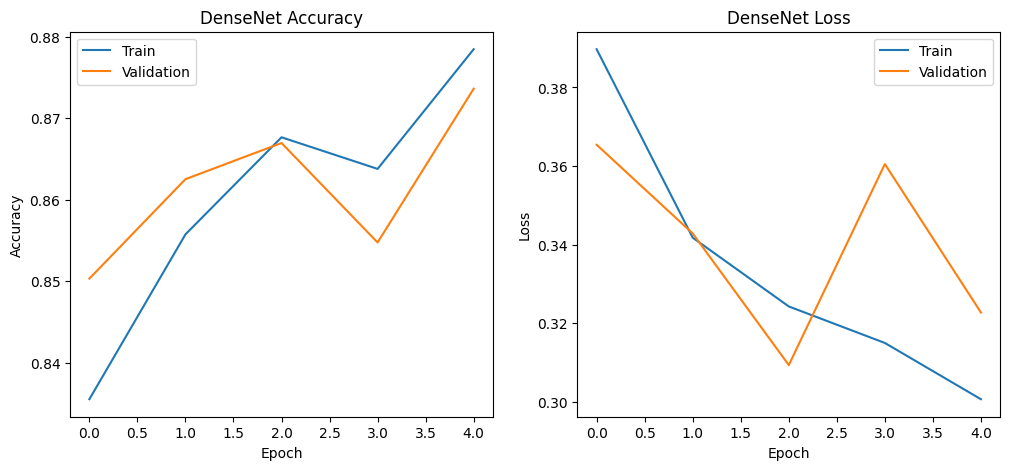

In [44]:
# Example for Pre-trained model
metrics, y_true, y_pred = compute_metrics(model, val_generator)
print(metrics)
plot_confusion_matrix(y_true, y_pred)
plot_training_history(history, 'DenseNet')